In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.insert(0, '../..')
import matplotlib.pyplot as plt

from attn_bench.plotting.utils import SEQ_LEN
from attn_bench.plotting.data_loading import load_doc_lengths, load_packed_chunk_length_hist
from attn_bench.plotting.doc_lengths import (
    print_doc_length_stats, plot_doc_length_histogram, plot_doc_length_overlay,
    range_budget, plot_token_budget, chunk_hist_stats, print_chunk_stats,
    plot_chunk_length_histogram, plot_doc_vs_chunk_length,
)

# Dataset stats: doc lengths, tokens

Per-document token-length distributions from `dataset_doc_stats.py`. Reads from `results/datasets/analysis/doc-lengths/`. Outputs #docs, #tokens, mean, std,  min / max, percentiles

In [5]:
datasets = load_doc_lengths()
print('loaded:', list(datasets))

loaded: ['fineweb-edu-dedup-160B-datatrove', 'fineweb-edu-dedup-160B-datatrove_0.25', 'fineweb-edu-dedup-160B-datatrove_long_40B', 'fineweb-edu-dedup-160B-datatrove_long_40B_split1024', 'gutenberg_rep_1_256']


In [6]:
for name, lengths in datasets.items():
    print_doc_length_stats(name, lengths)

### fineweb-edu-full ###
  documents:    161,370,257
  total tokens: 160,159,943,902
  mean:         992.5
  std:          1,873.0
  min / max:    29 / 266,969
  percentiles:  p1=97  p5=149  p25=326  p50=607  p75=1,070  p90=1,868  p95=2,824  p99=7,358
### fineweb-edu-0.25 ###
  documents:    40,342,565
  total tokens: 40,038,865,413
  mean:         992.5
  std:          1,873.7
  min / max:    34 / 196,868
  percentiles:  p1=97  p5=149  p25=326  p50=607  p75=1,071  p90=1,868  p95=2,823  p99=7,348
### fineweb-edu-dedup-160B-datatrove_long_40B ###
  documents:    5,286,174
  total tokens: 40,000,002,920
  mean:         7,566.9
  std:          7,109.8
  min / max:    3,653 / 266,969
  percentiles:  p1=3,674  p5=3,764  p25=4,350  p50=5,560  p75=8,162  p90=12,561  p95=17,046  p99=33,639
### fineweb-edu-dedup-160B-datatrove_long_40B_split1024 ###
  documents:    40,404,234
  total tokens: 40,070,239,040
  mean:         991.7
  std:          131.9
  min / max:    258 / 1,279
  percentiles:  p

## Per-dataset histograms (document length)

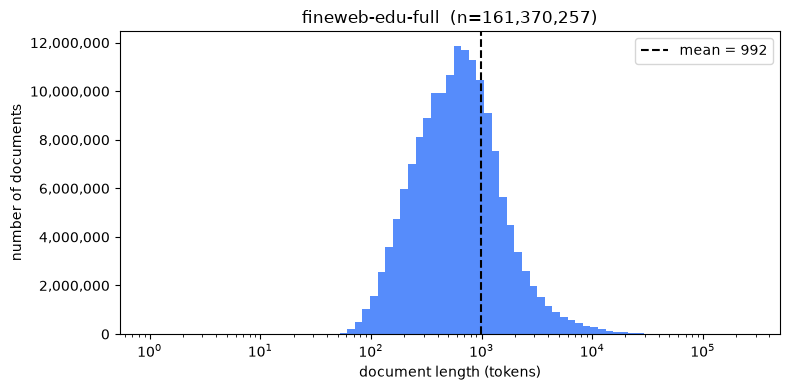

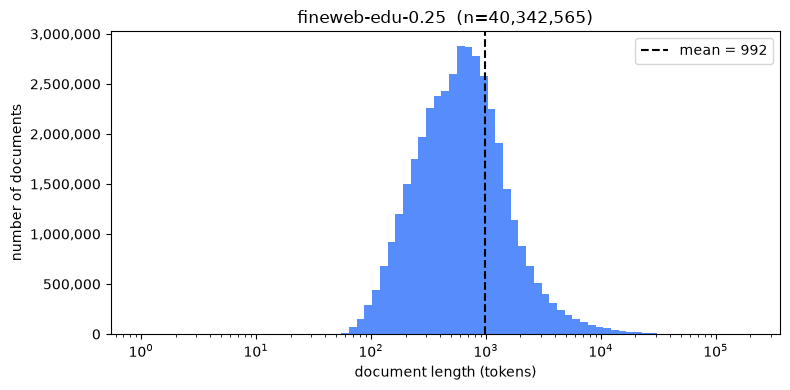

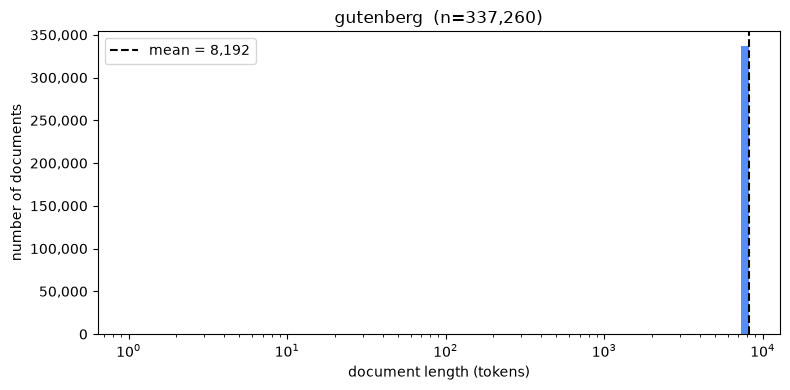

In [10]:
dataset_names = [
    'fineweb-edu-dedup-160B-datatrove',
    'fineweb-edu-dedup-160B-datatrove_0.25',
    # 'fineweb-edu-dedup-160B-datatrove_long_40B',
    # 'fineweb-edu-dedup-160B-datatrove_long_40B_split1024',
    'gutenberg_rep_1_256'
]

for name, lengths in datasets.items():
    if name not in dataset_names:
        continue
    plot_doc_length_histogram(name, lengths)
    plt.show()

## Overlaid per-dataset histograms (document length)
To compare datasets to each other at the same scale


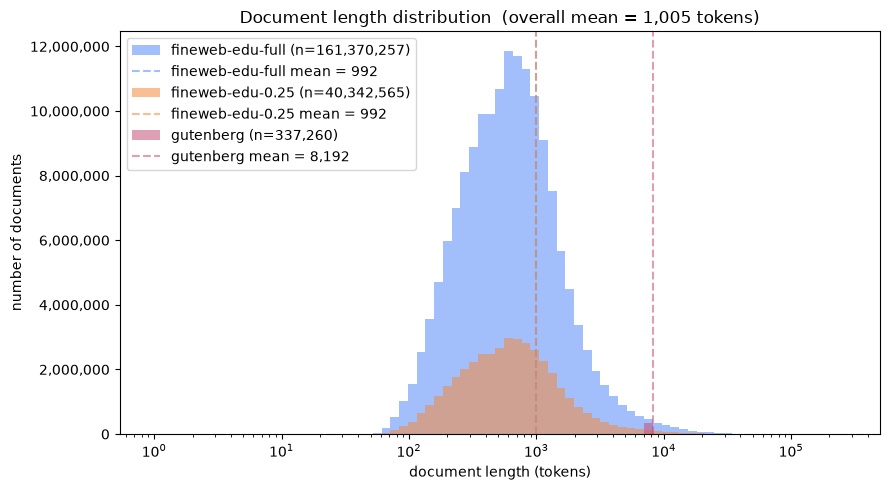

In [12]:
# Comment out a line to drop that dataset from the overlay below.
OVERLAY_DATASETS = [
    'fineweb-edu-dedup-160B-datatrove',  # full 160B set -- redundant with the 0.25 subset, dominates the plot
    'fineweb-edu-dedup-160B-datatrove_0.25',
    # 'fineweb-edu-dedup-160B-datatrove_long_40B',
    # 'fineweb-edu-dedup-160B-datatrove_long_40B_split1024',
    'gutenberg_rep_1_256',
]

plot_doc_length_overlay(datasets, models=OVERLAY_DATASETS)
plt.show()

# Token budget by doc length

How many tokens (not documents) sit in each length range -- for length-informed data
selection. `range_budget(lengths, lo, hi)` gives one range's budget; `plot_token_budget`
charts it per bin against the cumulative "docs >= x" curve.

In [13]:
# Examples on the full fineweb-edu set -- edit the range for whatever subset you're considering.
fw = datasets['fineweb-edu-dedup-160B-datatrove']
range_budget(fw, 3650)
range_budget(fw, 0, 3650)

[3,650, inf): 5,294,858 docs, 40.03B tokens (25.0% of 160.2B)
[0, 3,650): 156,075,399 docs, 120.13B tokens (75.0% of 160.2B)


## Distribution of token budget based on the doc lengths
per doc length bin + cumulative for overall token budget

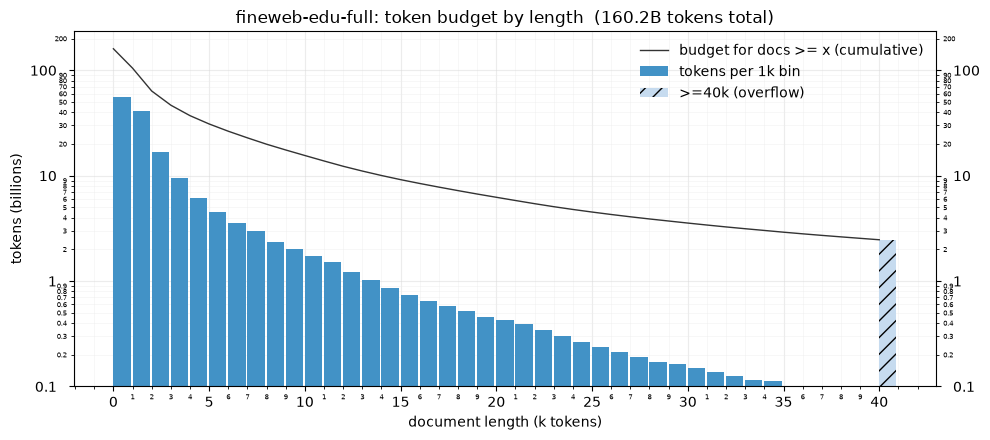

In [14]:
# Skips the 0.25 subset (redundant with the full 160B set) and gutenberg (fixed length,
# no distribution to show).
dataset_names = [
    'fineweb-edu-dedup-160B-datatrove',
    # 'fineweb-edu-dedup-160B-datatrove_0.25',
    # 'fineweb-edu-dedup-160B-datatrove_long_40B',
    # 'fineweb-edu-dedup-160B-datatrove_long_40B_split1024',
    # 'gutenberg_rep_1_256'
]

# if I filter my training data by document length, how many tokens do I actually keep?
# bars -- 1k-token length bin
# line -- cumulative
for name, lengths in datasets.items():
    if name not in dataset_names:
        continue
    plot_token_budget(name, lengths, max_tok=40000)
    plt.show()

In [16]:
# Checking token budgets for very long documents
LO, HI = 3 * SEQ_LEN, 4 * SEQ_LEN
for name in ('fineweb-edu-dedup-160B-datatrove_0.25', 'fineweb-edu-dedup-160B-datatrove'):
    range_budget(datasets[name], LO, HI)

[24,576, 32,768): 13,125 docs, 0.37B tokens (0.9% of 40.0B)
[24,576, 32,768): 52,153 docs, 1.46B tokens (0.9% of 160.2B)


# Packed chunk-length distribution

What the model actually attends to per sample: documents packed into fixed `seq_len`
windows for one epoch (`packed_chunk_stats.py`), so a chunk ends at the document's end or
the window's end, whichever comes first. Reads from `results/datasets/packed_chunk_lengths/`.

In [17]:
chunk_data = load_packed_chunk_length_hist()
chunk_hists = {name: hist for name, (hist, _) in chunk_data.items()}

for name, (hist, job_id) in chunk_data.items():
    print_chunk_stats(name, chunk_hist_stats(hist), job_id)

### fineweb-edu-0.25 ###  (job 2765239)
  chunks:       45,224,954
  mean:         885.3
  std:          1,096.5
  min / max:    1 / 8,192
  percentiles:  p1=47  p5=123  p25=297  p50=567  p75=1,019  p90=1,799  p95=2,716  p99=6,503
### fineweb-edu-dedup-160B-datatrove_long_40B ###  (job 2765331)
  chunks:       10,168,340
  mean:         3,933.8
  std:          2,397.6
  min / max:    1 / 8,192
  percentiles:  p1=79  p5=395  p25=1,971  p50=3,800  p75=5,522  p90=8,192  p95=8,192  p99=8,192
### fineweb-edu-dedup-160B-datatrove_long_40B_split1024 ###  (job 2765419)
  chunks:       45,290,630
  mean:         884.7
  std:          270.6
  min / max:    1 / 1,279
  percentiles:  p1=46  p5=230  p25=871  p50=1,024  p75=1,024  p90=1,024  p95=1,024  p99=1,170
### gutenberg ###  (job 2765239)
  chunks:       337,251
  mean:         8,192.0
  std:          0.0
  min / max:    8,192 / 8,192
  percentiles:  p1=8,192  p5=8,192  p25=8,192  p50=8,192  p75=8,192  p90=8,192  p95=8,192  p99=8,192


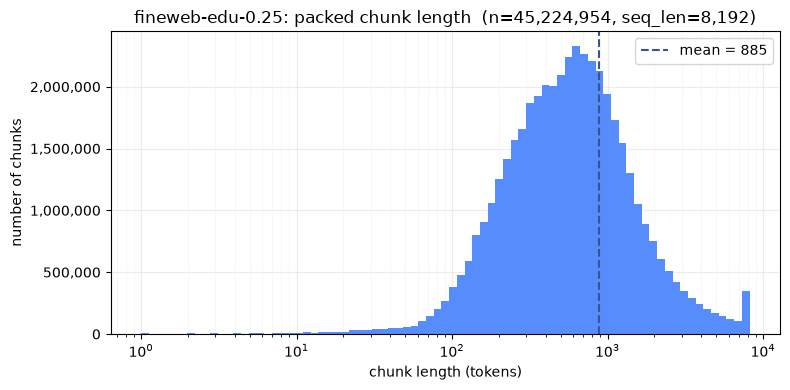

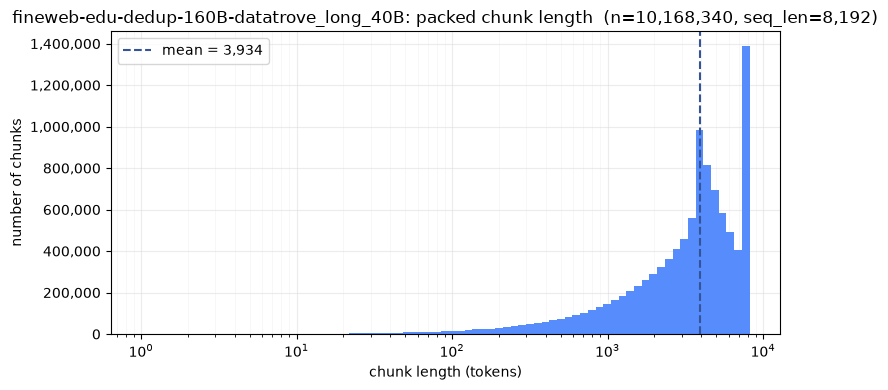

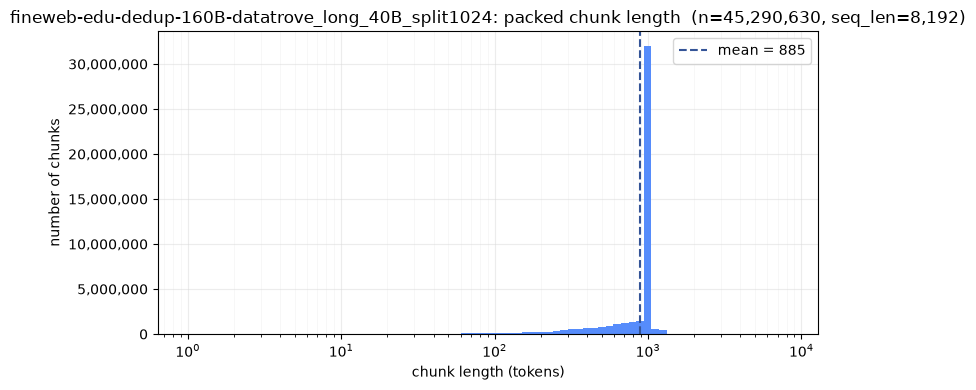

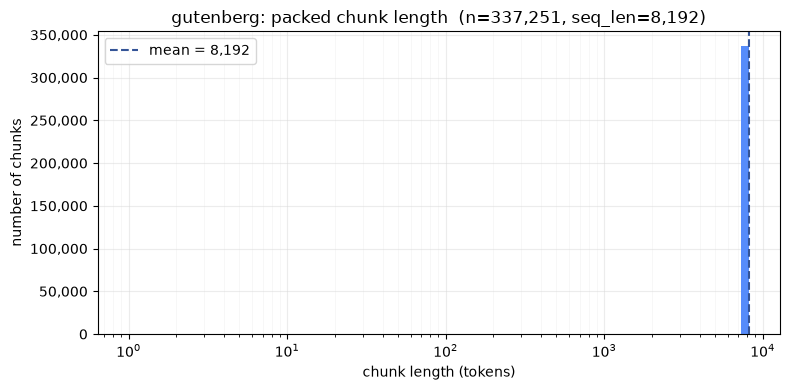

In [20]:
for name, hist in chunk_hists.items():
    plot_chunk_length_histogram(name, hist)
    plt.show()

## Doc length vs packed chunk length

Same dataset, raw docs vs packed chunks overlaid: packing cuts docs longer than `seq_len`
into chunks (mass appears at/near `seq_len`), while short docs stay one chunk each.
FineWeb also has a small tail of sub-`seq_len` slivers (~0.02%) from docs straddling a
sample boundary.

Both `fineweb-edu-dedup-160B-datatrove_0.25` and `fineweb-edu-dedup-160B-datatrove_long_40B_split1024` accidentally have the same mean on the charts (992, 885), checked, it's correct. Actual numbers are 992.5 vs 991.7, and 885.3 vs 884.7. This accidental fact can help to test the hypothesis about the perplexity spike mid-sequence and its connection to doc length distribution

plotting: ['fineweb-edu-dedup-160B-datatrove_0.25', 'fineweb-edu-dedup-160B-datatrove_long_40B', 'fineweb-edu-dedup-160B-datatrove_long_40B_split1024', 'gutenberg_rep_1_256']


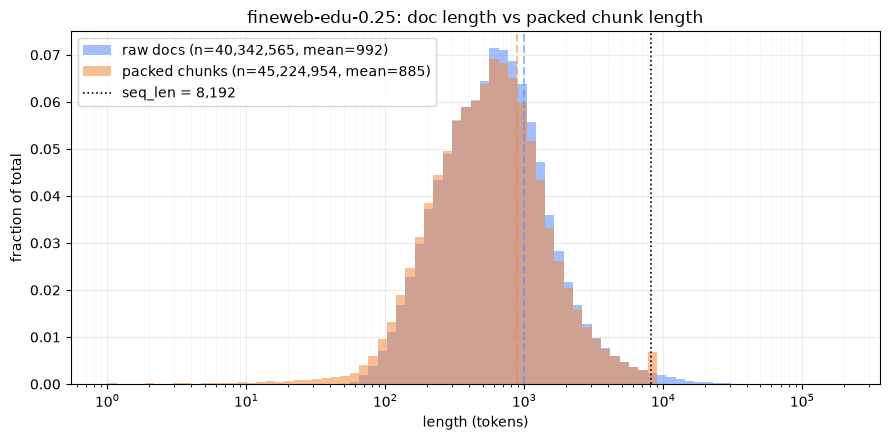

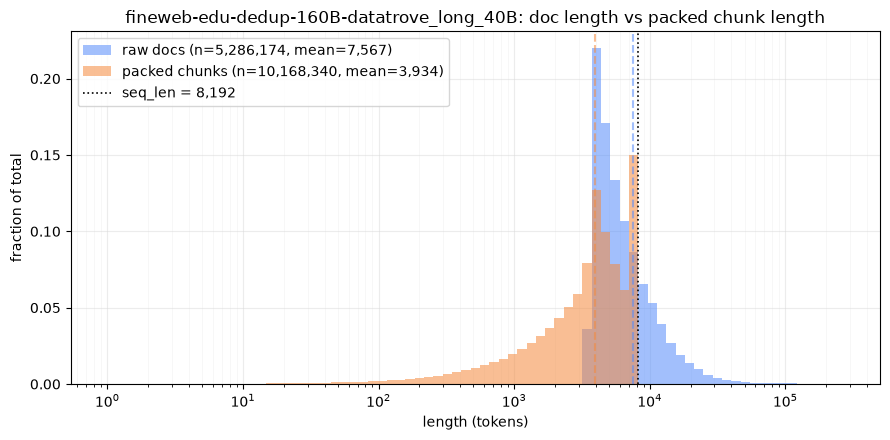

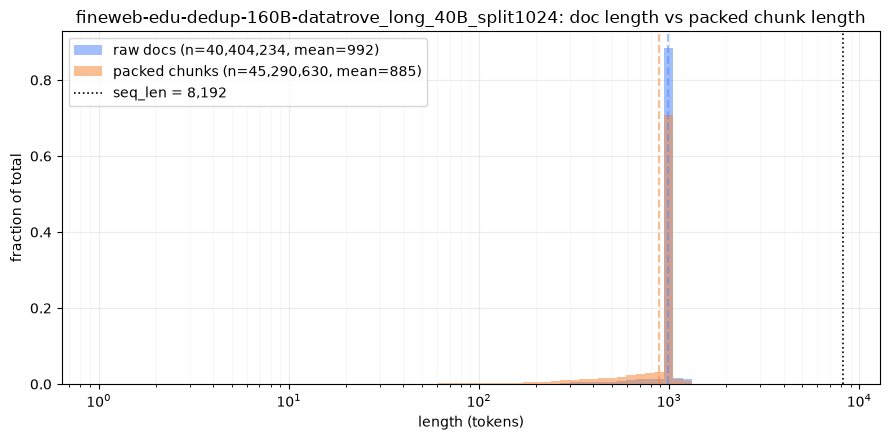

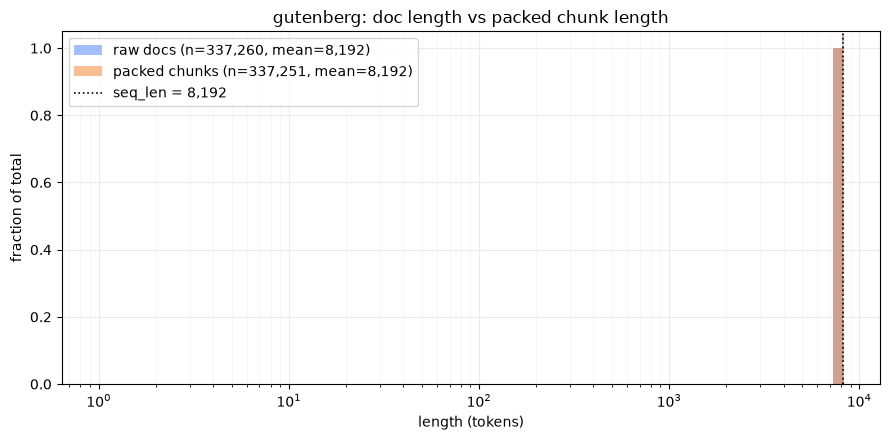

In [21]:
common = sorted(set(datasets) & set(chunk_hists))
print('plotting:', common)

dataset_names = [
    'fineweb-edu-dedup-160B-datatrove_0.25',
    'fineweb-edu-dedup-160B-datatrove_long_40B',
    'fineweb-edu-dedup-160B-datatrove_long_40B_split1024',
    'gutenberg_rep_1_256'
]

for name in common:
    if name not in dataset_names:
        continue
    plot_doc_vs_chunk_length(name, datasets[name], chunk_hists[name])
    plt.show()